#### 데이터셋 선택 (Select a dataset)

이번에는 United States Department of Transportation 의 항공 지연 데이터를 사용합니다.

이 데이터는:
* 각 행(row) = 월(month)
* 각 열(column) = 항공사 코드
를 의미합니다.

예:
* 1 = January
* 2 = February

#### 데이터 의미

각 값은:
해당 월의 평균 도착 지연 시간(분)
입니다.

#### 예시

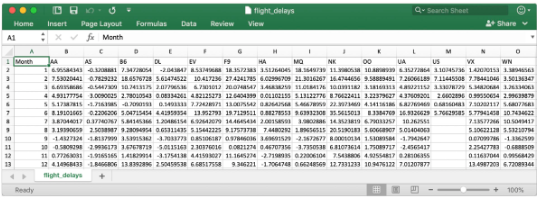

* AA(아메리칸 항공) 1월 평균:
→ 약 7분 지연
* AS(알래스카 항공) 4월 평균:
→ 약 3분 빨리 도착

#### 데이터 불러오기 (Load the data)

```python
# Path of the file to read
flight_filepath = "../input/flight_delays.csv"

# Read the file into a variable flight_data
flight_data = pd.read_csv(flight_filepath, index_col="Month")
```


#### 이전 튜토리얼과 차이점

이전에는:
```python
parse_dates=True
```
를 사용했지만 이번에는 없습니다.

이유:
* Month는 날짜(date)가 아니라 단순 숫자이기 때문

즉:
* 날짜 변환 불필요
* index_col만 설정

#### 데이터 확인하기 (Examine the data)

```python
flight_data
```
데이터셋 이름만 적어도 전체 데이터가 출력됩니다.

#### 데이터 해석 예시

| Month | NK    |
| ----- | ----- |
| 1     | 11.39 |
| 6     | 35.56 |

→ 6월에 Spirit Airlines(NK)는 평균 35분 이상 지연됨

#### Bar Chart (막대 그래프)

목표:
Spirit Airlines(NK)의 월별 평균 도착 지연 시간 시각화

#### 코드

```python
# Set the width and height of the figure
plt.figure(figsize=(10,6))

# Add title
plt.title("Average Arrival Delay for Spirit Airlines Flights, by Month")

# Bar chart showing average arrival delay for Spirit Airlines flights by month
sns.barplot(x=flight_data.index, y=flight_data['NK'])

# Add label for vertical axis
plt.ylabel("Arrival delay (in minutes)")
```

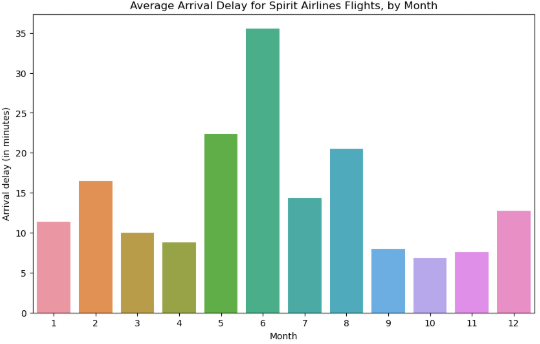

#### 코드 설명

* 그래프 크기

```python
plt.figure(figsize=(10,6))
```
가로 10, 세로 6 크기

* 제목 추가

```python
plt.title(...)
```
그래프 제목 설정

* 핵심: Bar Plot

```python
sns.barplot(
    x=flight_data.index,
    y=flight_data['NK']
)
```

#### 구성 요소 설명

1. sns.barplot
막대 그래프 생성

2. x=flight_data.index
x축 = Month

주의:
```python
flight_data['Month']
```
는 사용 불가!
왜냐하면 Month는 이미 index로 사용되었기 때문입니다.

따라서 반드시:
```python
flight_data.index
```
를 사용해야 합니다.

3. y=flight_data['NK']
막대 높이 값

즉:
* NK 컬럼의 값
* Spirit Airlines 지연 시간

#### y축 라벨 추가

```python
plt.ylabel("Arrival delay (in minutes)")
```
세로축 이름 설정

#### Heatmap (히트맵)

이번에는 히트맵을 배웁니다.

히트맵은:
색깔로 데이터 크기를 표현하는 시각화
입니다.

#### 코드

```python
# Set the width and height of the figure
plt.figure(figsize=(14,7))

# Add title
plt.title("Average Arrival Delay for Each Airline, by Month")

# Heatmap showing average arrival delay for each airline by month
sns.heatmap(data=flight_data, annot=True)

# Add label for horizontal axis
plt.xlabel("Airline")
```

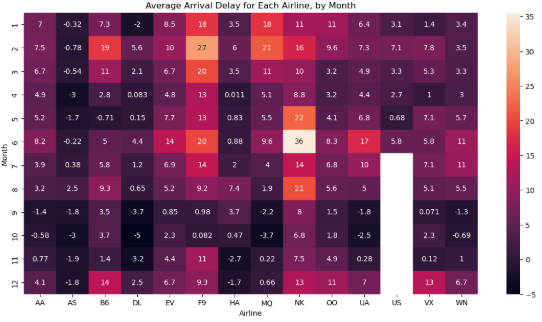

#### 핵심 코드 설명

* sns.heatmap
```python
sns.heatmap(...)
```
히트맵 생성

* data=flight_data
전체 데이터 사용

* annot=True
각 셀 안에 숫자 표시

만약 생략하면:
* 색깔만 보이고
* 숫자는 안 나옴

#### Heatmap 해석하기

색이 진할수록:
* 값이 큼
* 지연 시간이 큼

색이 연할수록:
* 값이 작음
* 덜 지연됨

#### 튜토리얼에서 발견한 패턴

9~11월은 대부분 항공사가 색이 상대적으로 어둡지 않음.

즉:
이 시기에는 항공사들이 평균적으로 스케줄을 더 잘 지킨다
는 의미입니다.